In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

loan= pd.read_csv('loan_applicants.csv') 

print('Dataset shape:', loan.shape)
print()
loan.tail(10)

Dataset shape: (20, 5)



,applicant_id,monthly_income,credit_score,employment_years,loan_approved
10,APP-1011,80451,840,7,0
11,APP-1012,509158,807,17,1
12,APP-1013,294406,653,7,1
13,APP-1014,759727,524,14,0
14,APP-1015,353858,322,13,0
15,APP-1016,633484,402,5,0
16,APP-1017,709924,603,3,1
17,APP-1018,398856,812,13,1
18,APP-1019,582380,494,9,0
19,APP-1020,347962,811,16,1


In [6]:
X = loan[['monthly_income', 'credit_score', 'employment_years']]
y = loan['loan_approved']

print('Features (X) - 3 columns, 20 rows:')
print(X.head(3))
print()
print('Label (y) - what we want to predict:')
print(y.values)
print(f'Approved: {y.sum()} | Rejected: {(y==0).sum()}')

Features (X) - 3 columns, 20 rows:
   monthly_income  credit_score  employment_years
0          190891           364                 8
1          173646           807                14
2          545185           688                 6

Label (y) - what we want to predict:
[0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1]
Approved: 7 | Rejected: 13


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)} applicants')
print(f'Test set:     {len(X_test)} applicants')
print()

# Train the ML model - it learns the rules from training data
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)   # <-- this is where learning happens

print('Model trained. It has now seen', len(X_train), 'examples.')
print('It learned patterns - no rules were written by hand.')

Training set: 16 applicants
Test set:     4 applicants

Model trained. It has now seen 16 examples.
It learned patterns - no rules were written by hand.


In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Test set predictions vs actual decisions:')
print(f'{"Actual":<12} {"ML Predicted":<15} {"Match?"}')
print('-' * 35)
for actual, predicted in zip(y_test, y_pred):
    match = 'YES' if actual == predicted else 'NO'
    label_a = 'APPROVED' if actual    else 'REJECTED'
    label_p = 'APPROVED' if predicted else 'REJECTED'
    print(f'{label_a:<10} {label_p:<15} {match}')

print()
print(f'Accuracy: {accuracy*100:.0f}%')

Test set predictions vs actual decisions:
Actual       ML Predicted    Match?
-----------------------------------
REJECTED   REJECTED        YES
APPROVED   APPROVED        YES
REJECTED   REJECTED        YES
REJECTED   REJECTED        YES

Accuracy: 100%


In [11]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----

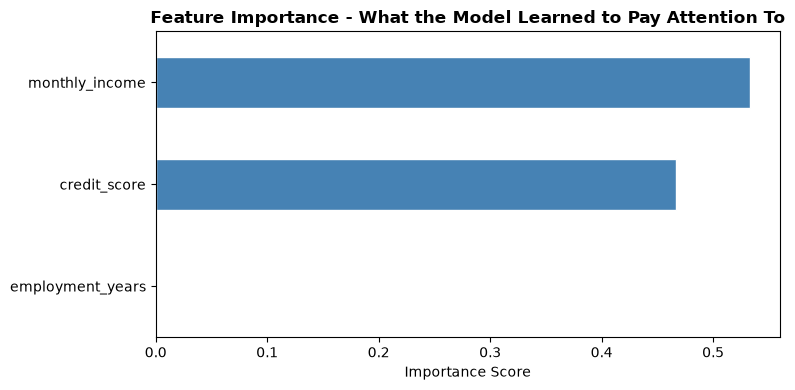

The model assigned importance to each feature based on the training data.
This is the pattern it learned - no human specified these weights.


In [12]:
import matplotlib.pyplot as plt

# Feature importance - which feature mattered most to the model?
importance = pd.Series(
    model.feature_importances_,
    index=['monthly_income', 'credit_score', 'employment_years']
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance - What the Model Learned to Pay Attention To',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('The model assigned importance to each feature based on the training data.')
print('This is the pattern it learned - no human specified these weights.')